In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension
from utils.util import  get_dataframe_from_filepath,calculate_statistics, extract_unique_mbps_and_ms
from utils.util import remove_outliers_iqr, comma_format, create_directory_if_not_exists,print_rtt_stats,save_rtt_stats,return_rtt_stats

In [2]:
# Load data
mainpth="../data/udp_data_2025-05-03"

graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/client1_data',mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '.log')


Directory already exists: ../data/udp_data_2025-05-03\Graphs
Directory already exists: ../data/udp_data_2025-05-03\Stats


In [3]:
filedict

{'1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log': '../data/udp_data_2025-05-03/client1_data\\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
 '2_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log': '../data/udp_data_2025-05-03/client1_data\\2_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
 '3_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log': '../data/udp_data_2025-05-03/client1_data\\3_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
 '1_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log': '../data/udp_data_2025-05-03/client2_data\\1_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log',
 '2_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log': '../data/udp_data_2025-05-03/client2_data\\2_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log',
 '3_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log': '../data/udp_data_2025-05-03/client2_data\\3_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log'}

In [4]:
folderpaths

['../data/udp_data_2025-05-03/client1_data',
 '../data/udp_data_2025-05-03/client2_data']

In [5]:
# Call the function and print unique combinations
unique_combinations = extract_unique_mbps_and_ms(folderpaths)
print("Unique Mbps and ms Combinations:")
for mbps, ms in sorted(unique_combinations):
    print(f'{mbps} Mbps, {ms} ms')


Unique Mbps and ms Combinations:
8 Mbps, 10 ms


In [6]:
mbps , ms = list(unique_combinations)[0]
net_settings = f'{mbps}_Mbps_{ms}_ms'
print(net_settings)

8_Mbps_10_ms


In [7]:
df=get_dataframe_from_filepath(filepaths[0])
df['ForeignPort'].unique()

../data/udp_data_2025-05-03/client1_data\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log


array(['64301', '64311', '64321', '64320'], dtype=object)

In [8]:
unique_scenarios_dict={}
for index in range(len(filenames)):
    scenario = "_".join(filenames[index].split('_')[:5])
    if "l4s" in scenario:
        scenario = "_".join(filenames[index].split('_')[:4])
    if scenario in unique_scenarios_dict:
        unique_scenarios_dict[scenario].append(filedict[filenames[index]])
    else:
        unique_scenarios_dict[scenario]=[filedict[filenames[index]]]


In [9]:
unique_scenarios_dict

{'1_dualpi2_8Mbps_10ms_ecn': ['../data/udp_data_2025-05-03/client1_data\\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
  '../data/udp_data_2025-05-03/client2_data\\1_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log'],
 '2_dualpi2_8Mbps_10ms_ecn': ['../data/udp_data_2025-05-03/client1_data\\2_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
  '../data/udp_data_2025-05-03/client2_data\\2_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log'],
 '3_dualpi2_8Mbps_10ms_ecn': ['../data/udp_data_2025-05-03/client1_data\\3_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
  '../data/udp_data_2025-05-03/client2_data\\3_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log']}

In [10]:
from utils.plotter import  plot_siftr_graph

In [11]:
unique_scenarios_dict

{'1_dualpi2_8Mbps_10ms_ecn': ['../data/udp_data_2025-05-03/client1_data\\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
  '../data/udp_data_2025-05-03/client2_data\\1_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log'],
 '2_dualpi2_8Mbps_10ms_ecn': ['../data/udp_data_2025-05-03/client1_data\\2_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
  '../data/udp_data_2025-05-03/client2_data\\2_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log'],
 '3_dualpi2_8Mbps_10ms_ecn': ['../data/udp_data_2025-05-03/client1_data\\3_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log',
  '../data/udp_data_2025-05-03/client2_data\\3_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log']}


Start New Scenario
1_dualpi2_8Mbps_10ms_ecn
['../data/udp_data_2025-05-03/client1_data\\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log', '../data/udp_data_2025-05-03/client2_data\\1_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-05-03/client2_data\1_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log
../data/udp_data_2025-05-03/client2_data\1_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log
      Direction        Time     LocalIP LocalPort   ForeignIP ForeignPort  \
107           o    7.927837  172.16.5.2     35252  172.16.1.2        5102   
109           o    7.928287  172.16.5.2     35252  172.16.1.2        5102   
114           o    8.031317  172.16.5.2     35252  172.16.1.2        5102   
115           o    8.031354  172.16.5.2     35252  172.16.1.2        5102   
122           o    8.223468  172.16.5.2     23703  172.16.1.2        5102   
...         ...         ...         ...       ...         ...         ...   
16052         o  129.5779

2025-05-21 08:26:23,663 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-05-21 08:26:23,664 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-05-21 08:26:23,666 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-05-21 08:26:23,667 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 2.335
2025-05-21 08:26:23,667 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizTwoSymReg.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-05-21 08:26:23,667 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols

Statistics for NEWRENO:
Median: 443.437
Mean: 459.7875852115461
25th Percentile: 340.0
75th Percentile: 570.312
Minimum: 183.437
Maximum: 932.187
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/udp_data_2025-05-03\Stats/scn_1_dualpi2_8Mbps_10ms_ecn_rtt_stats.txt



2025-05-21 08:26:23,679 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-05-21 08:26:23,680 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXNonUniBol.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2025-05-21 08:26:23,680 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2025-05-21 08:26:23,680 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\deols\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\

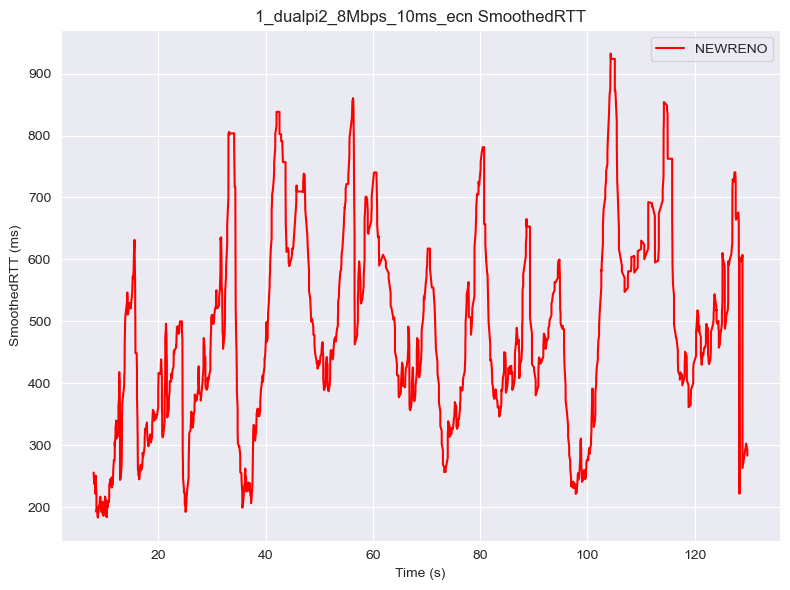

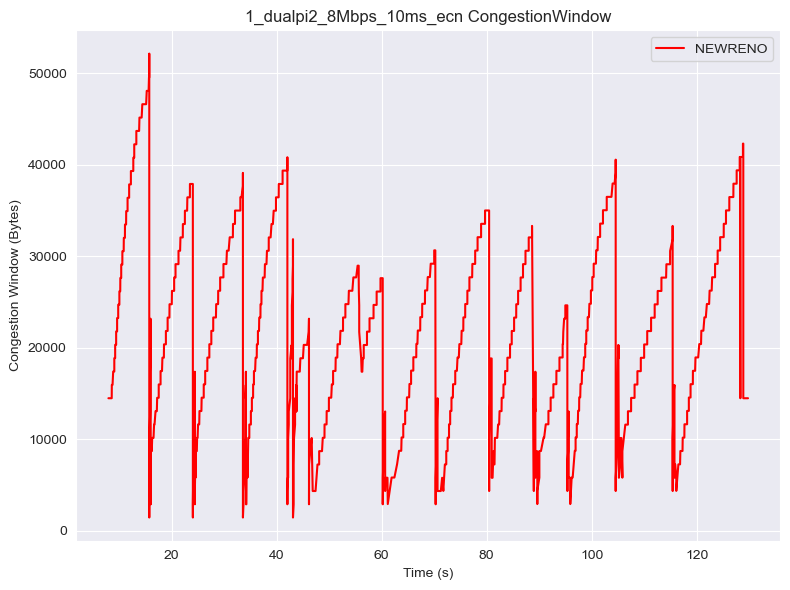


Start New Scenario
2_dualpi2_8Mbps_10ms_ecn
['../data/udp_data_2025-05-03/client1_data\\2_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log', '../data/udp_data_2025-05-03/client2_data\\2_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-05-03/client2_data\2_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log
../data/udp_data_2025-05-03/client2_data\2_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log
      Direction        Time     LocalIP LocalPort   ForeignIP ForeignPort  \
109           o    8.075831  172.16.5.2     26279  172.16.1.2        5102   
111           o    8.077772  172.16.5.2     26279  172.16.1.2        5102   
116           o    8.236526  172.16.5.2     26279  172.16.1.2        5102   
117           o    8.236591  172.16.5.2     26279  172.16.1.2        5102   
122           o    8.392392  172.16.5.2     26279  172.16.1.2        5102   
...         ...         ...         ...       ...         ...         ...   
16507         o  129.8092

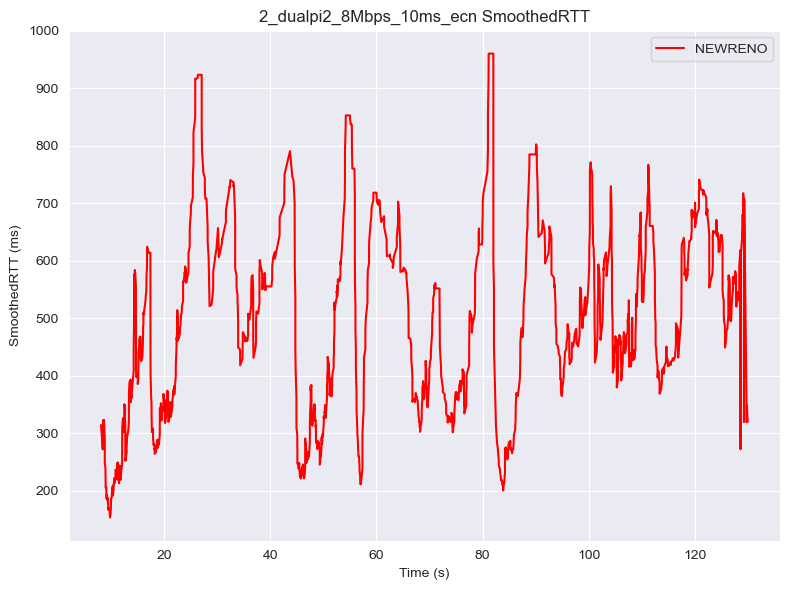

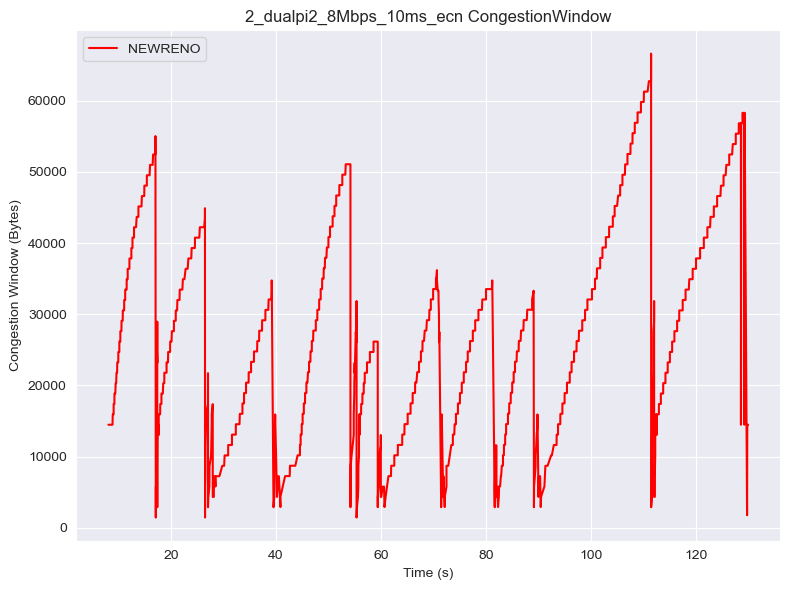


Start New Scenario
3_dualpi2_8Mbps_10ms_ecn
['../data/udp_data_2025-05-03/client1_data\\3_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src1.siftr.log', '../data/udp_data_2025-05-03/client2_data\\3_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-05-03/client2_data\3_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log
../data/udp_data_2025-05-03/client2_data\3_dualpi2_8Mbps_10ms_ecn_udp_newreno_src2.siftr.log
      Direction        Time     LocalIP LocalPort   ForeignIP ForeignPort  \
109           o    8.215824  172.16.5.2     37086  172.16.1.2        5102   
110           o    8.216036  172.16.5.2     37086  172.16.1.2        5102   
113           o    8.349844  172.16.5.2     37086  172.16.1.2        5102   
114           o    8.349844  172.16.5.2     37086  172.16.1.2        5102   
121           o    8.507905  172.16.5.2     37086  172.16.1.2        5102   
...         ...         ...         ...       ...         ...         ...   
16238         o  129.4582

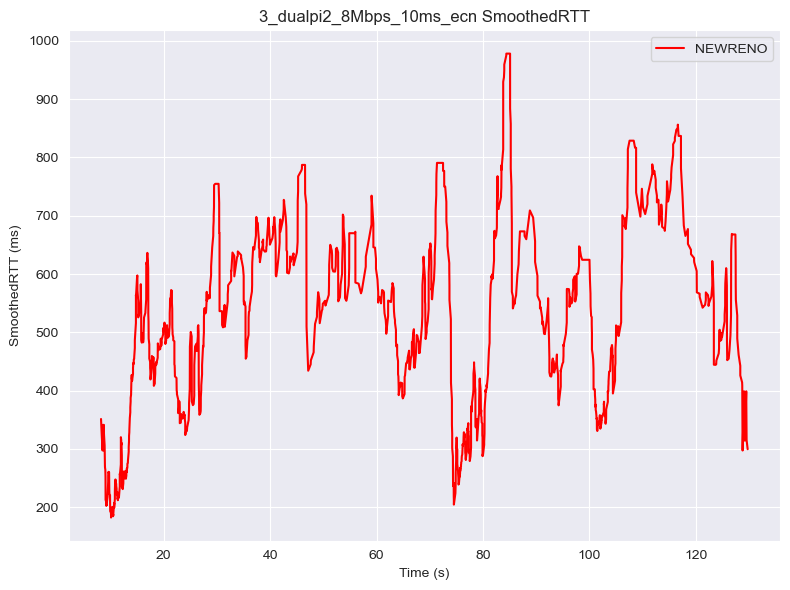

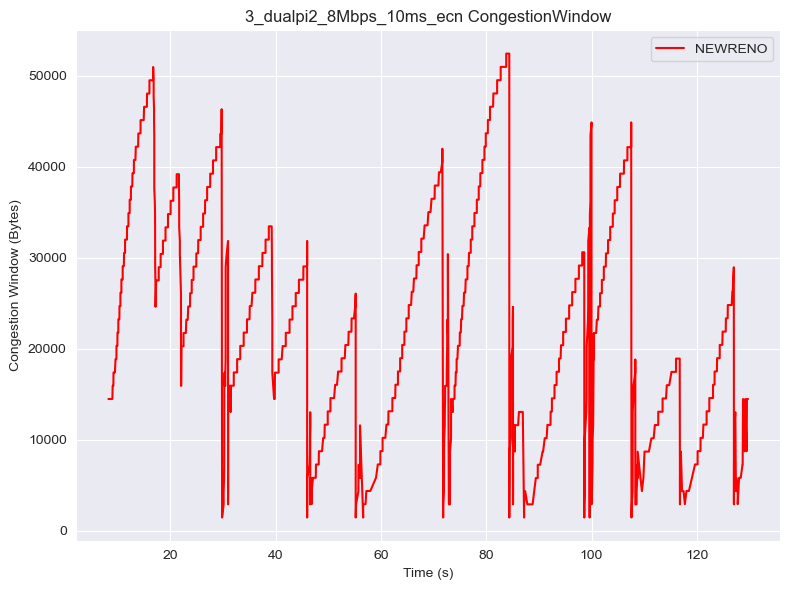

In [12]:
for scenario in unique_scenarios_dict.keys():

    print()
    print("Start New Scenario")
    print(scenario)
    print(unique_scenarios_dict[scenario])

    tcp_traffic = unique_scenarios_dict[scenario][1]

    print("tcp_traffic",tcp_traffic)


    ttf = get_dataframe_from_filepath(tcp_traffic)


    ttf = ttf[ttf['ForeignPort'] == "5102"]

    print(ttf)

    # Define paths
    paths = {
        "NEWRENO": ttf,
    }

    print_rtt_stats(paths=paths,scenario=scenario)
    save_rtt_stats(paths=paths,scenario=scenario,stats_directory=stats_directory)



    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )




    plot_siftr_graph(paths=paths,
                    ycolumn="CongestionWindow",
                    title=f"{scenario} CongestionWindow",
                    xlabel="Time (s)",
                    ylabel="Congestion Window (Bytes)",
                    filename=f'{scenario}_CWND',
                    graph_directory=graph_directory,
    )
